# Analysis of Regional Deployments

This notebook analyzes CSV files across different regions and deployments, examining:
- Number of files per deployment
- Date ranges for each deployment
- Distribution of records by date

In [2]:
# Import required libraries
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import glob
import os

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Summary

The notebook above will:

1. Find all regions matching the pattern `/gws/ssde/j25b/ceh_generic/kgoldmann/{region}_inferences/`
2. For each region, find all deployment directories (matching `dep*`)
3. For each deployment:
   - Count and print the number of CSV files
   - Read all CSV files and extract the date column
   - Collect all dates into a DataFrame
   - Print the start and end date for that deployment
   - Plot a bar chart showing the distribution of records by date
   - Display the top 5 dates by record count

All results are stored in the `results` dictionary for further analysis if needed.

In [3]:
base_path = Path('/gws/ssde/j25b/ceh_generic/kgoldmann/')

regions = os.listdir(base_path)
regions = [r.replace('_inferences', '') for r in regions if r.endswith('_inferences')]

regions

['costarica', 'kenya', 'thailand', 'singapore', 'panama']

In [4]:
def analyze_deployment(deployment_path, date_col = 'image_datetime' ):
    """
    Analyze a single deployment directory.
    Returns dict with file count, dates DataFrame, start date, end date.
    """
    # Find all CSV files in the deployment directory
    csv_files = list(deployment_path.glob("*.csv"))
    file_count = len(csv_files)

    if file_count == 0:
        return None

    # Collect all dates from all CSV files
    all_dates = []

    for csv_file in csv_files:
        try:
            # Read CSV and extract date column
            df = pd.read_csv(csv_file)

            # # Try to find date column (case-insensitive)
            # date_col = None
            # for col in df.columns:
            #     if 'date' in col.lower():
            #         date_col = col
            #         break

            if date_col:
                # Parse dates and add to collection
                dates = pd.to_datetime(df[date_col], errors='coerce')
                all_dates.extend(dates.dropna().tolist())
        except Exception as e:
            print(f"    Warning: Could not read {csv_file.name}: {e}")
            continue

    if not all_dates:
        return {'file_count': file_count, 'dates': None, 'start_date': None, 'end_date': None}

    # Create DataFrame of dates
    dates_df = pd.DataFrame({'date': all_dates})
    dates_df['date'] = pd.to_datetime(dates_df['date'])

    # Get date range
    start_date = dates_df['date'].min()
    end_date = dates_df['date'].max()

    return {
        'file_count': file_count,
        'dates': dates_df,
        'start_date': start_date,
        'end_date': end_date
    }


REGION: costarica

  Deployment: dep000031
  ------------------------------------------------------------
    Number of files: 239
    Start date: 2024-01-31
    End date: 2024-08-14
    Total records: 947931


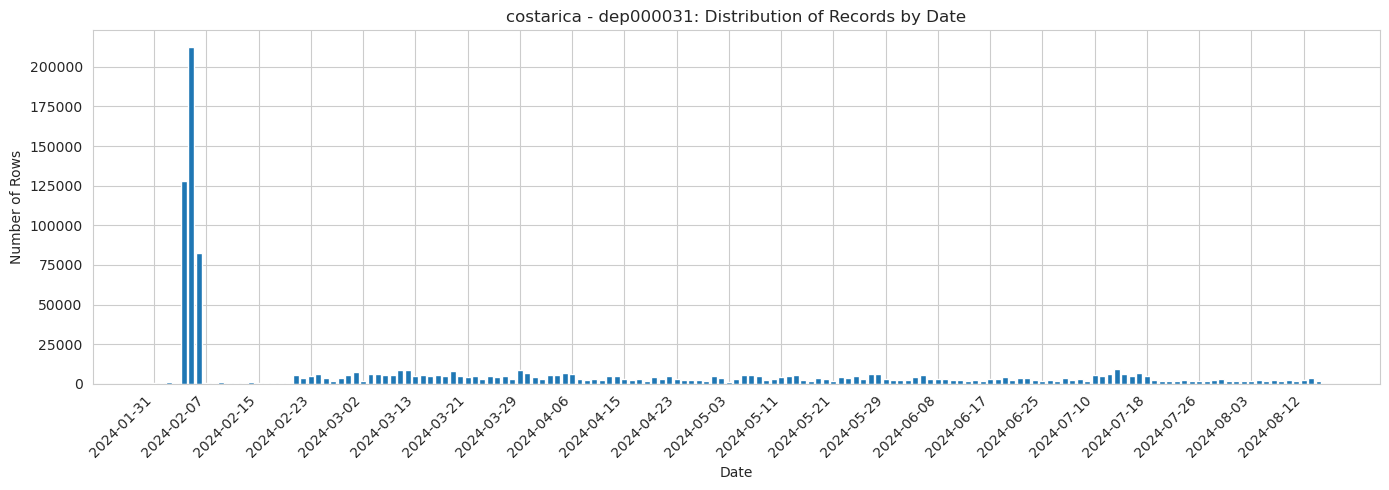


    Top 5 dates by record count:
      2024-01-31: 639 rows
      2024-02-01: 637 rows
      2024-02-02: 776 rows
      2024-02-03: 565 rows
      2024-02-04: 127802 rows

  Deployment: dep000032
  ------------------------------------------------------------
    Number of files: 508
    Start date: 2024-01-31
    End date: 2025-02-04
    Total records: 4661605


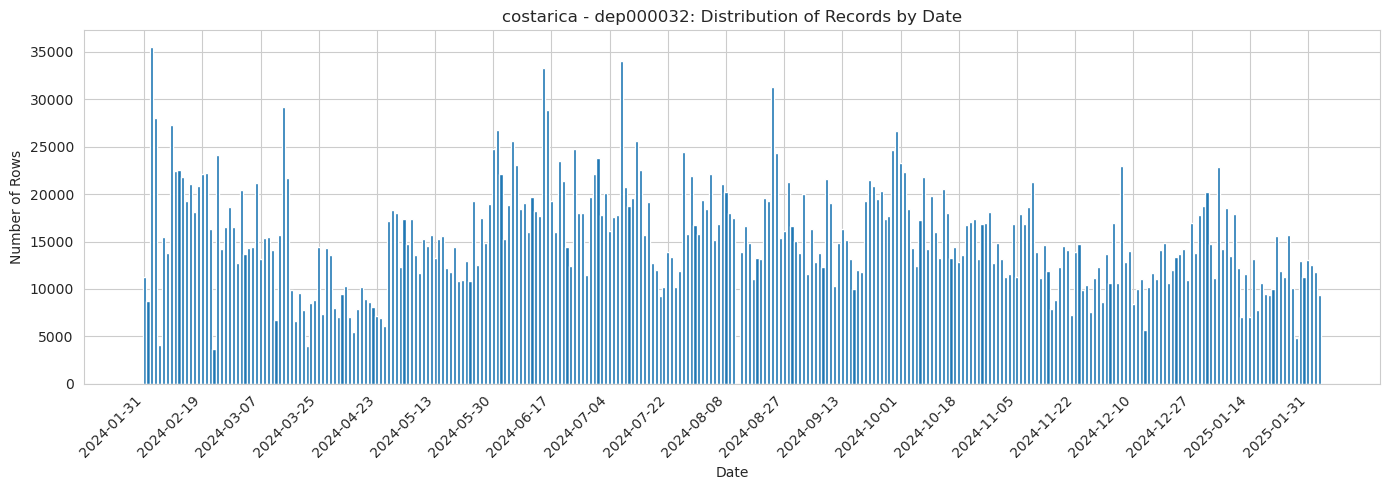


    Top 5 dates by record count:
      2024-01-31: 11241 rows
      2024-02-01: 8776 rows
      2024-02-02: 35502 rows
      2024-02-03: 28081 rows
      2024-02-05: 4061 rows

  Deployment: dep000033
  ------------------------------------------------------------


/tmp/ipykernel_841750/1216106133.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(df[date_col], errors='coerce')
/tmp/ipykernel_841750/1216106133.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(df[date_col], errors='coerce')


    Number of files: 430
    Start date: 2024-02-02
    End date: 2024-12-04
    Total records: 9487876


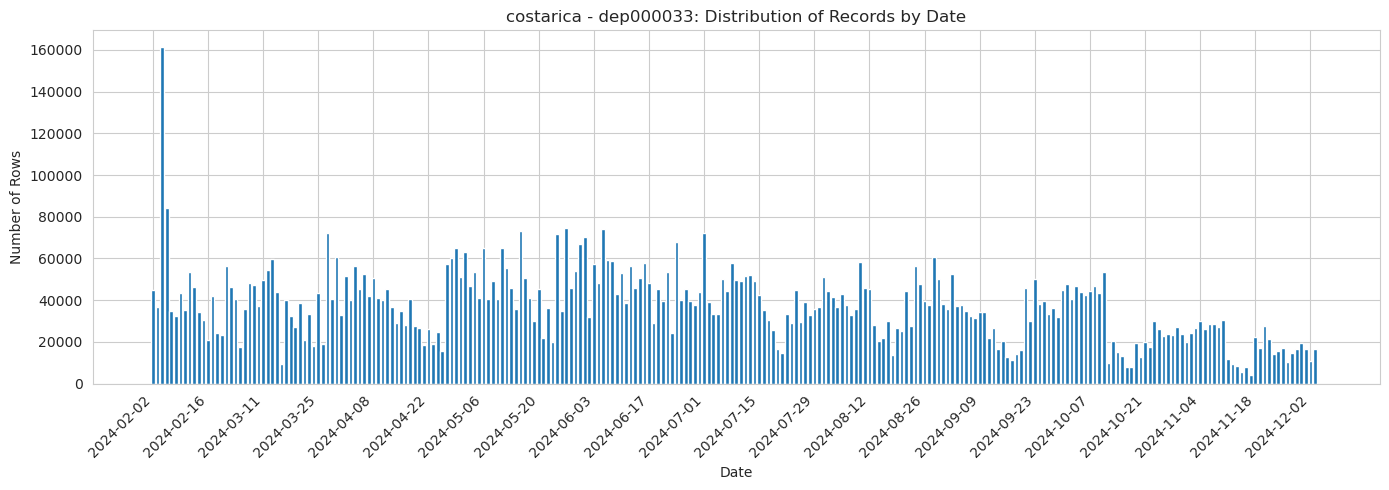


    Top 5 dates by record count:
      2024-02-02: 44762 rows
      2024-02-03: 36809 rows
      2024-02-05: 161252 rows
      2024-02-06: 84428 rows
      2024-02-07: 34763 rows

  Deployment: dep000034
  ------------------------------------------------------------
    Number of files: 233
    Start date: 2024-02-01
    End date: 2025-02-01
    Total records: 2633566


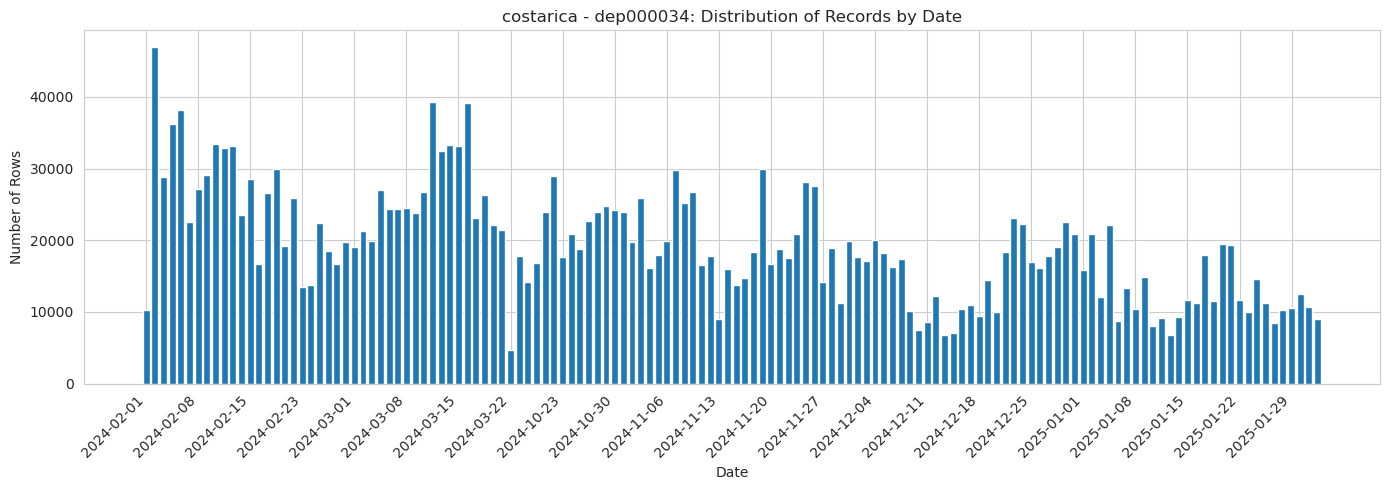


    Top 5 dates by record count:
      2024-02-01: 10327 rows
      2024-02-02: 46917 rows
      2024-02-03: 28846 rows
      2024-02-05: 36199 rows
      2024-02-06: 38186 rows

  Deployment: dep000035
  ------------------------------------------------------------
    Number of files: 5
    Start date: 2024-04-29
    End date: 2024-05-29
    Total records: 215089


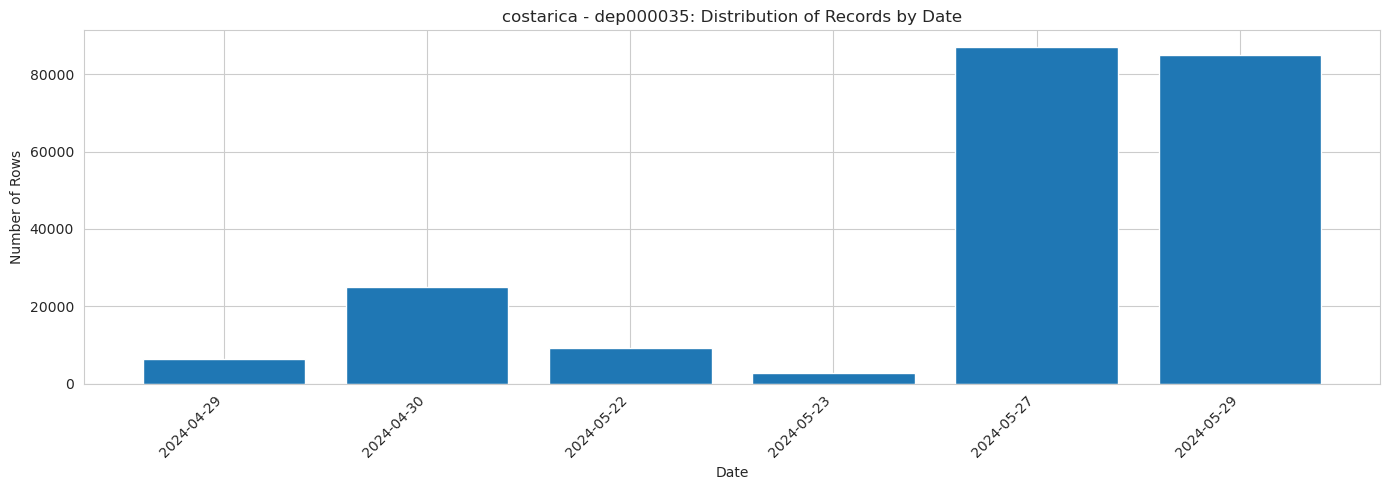


    Top 5 dates by record count:
      2024-04-29: 6342 rows
      2024-04-30: 24913 rows
      2024-05-22: 9184 rows
      2024-05-23: 2860 rows
      2024-05-27: 86965 rows

  Deployment: dep000036
  ------------------------------------------------------------
    Number of files: 5
    Start date: 2024-02-05
    End date: 2024-02-06
    Total records: 2470338


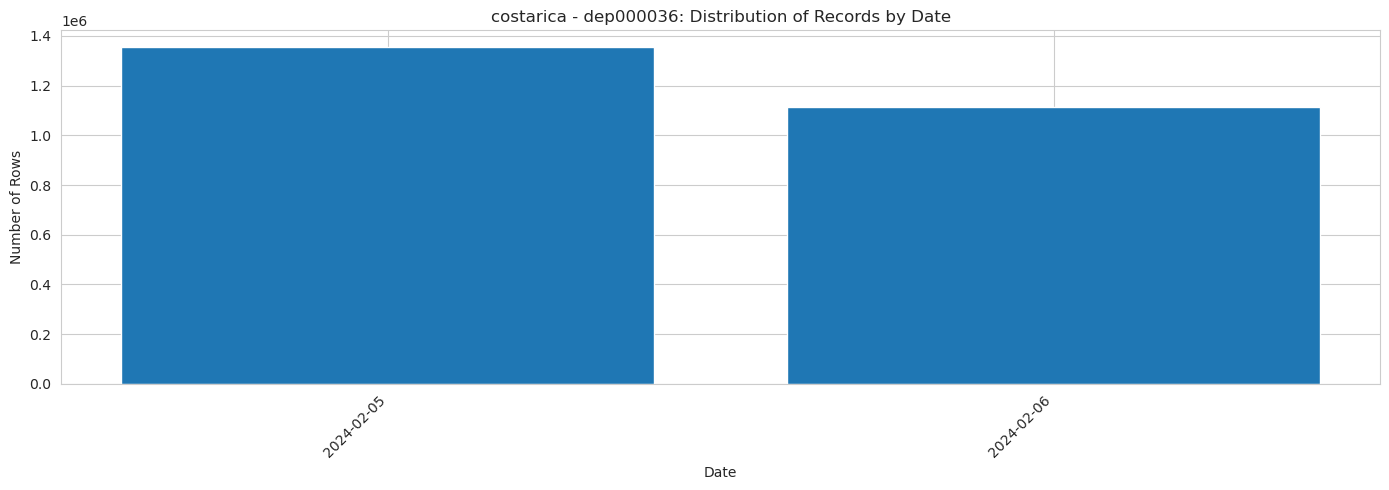


    Top 5 dates by record count:
      2024-02-05: 1354993 rows
      2024-02-06: 1115345 rows

  Deployment: dep000037
  ------------------------------------------------------------


/tmp/ipykernel_841750/1216106133.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(df[date_col], errors='coerce')


    Number of files: 288
    Start date: 2024-02-09
    End date: 2024-08-22
    Total records: 5704721


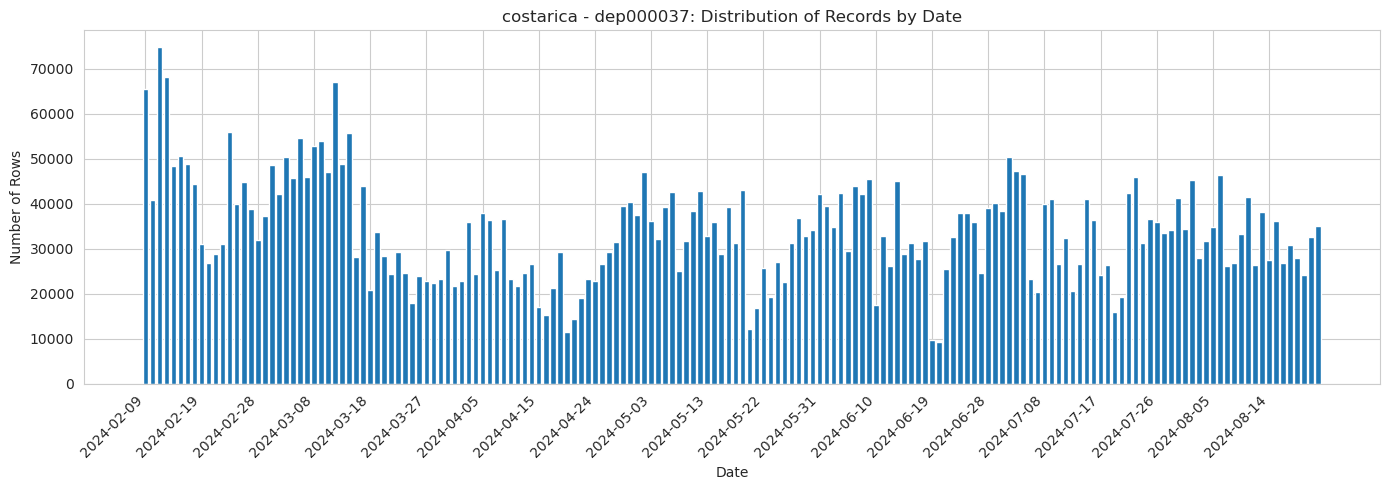


    Top 5 dates by record count:
      2024-02-09: 65573 rows
      2024-02-10: 40811 rows
      2024-02-12: 74829 rows
      2024-02-13: 68224 rows
      2024-02-14: 48511 rows

  Deployment: dep000038
  ------------------------------------------------------------


/tmp/ipykernel_841750/1216106133.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(df[date_col], errors='coerce')
/tmp/ipykernel_841750/1216106133.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(df[date_col], errors='coerce')


    Number of files: 258
    Start date: 2024-02-09
    End date: 2024-08-22
    Total records: 3041465


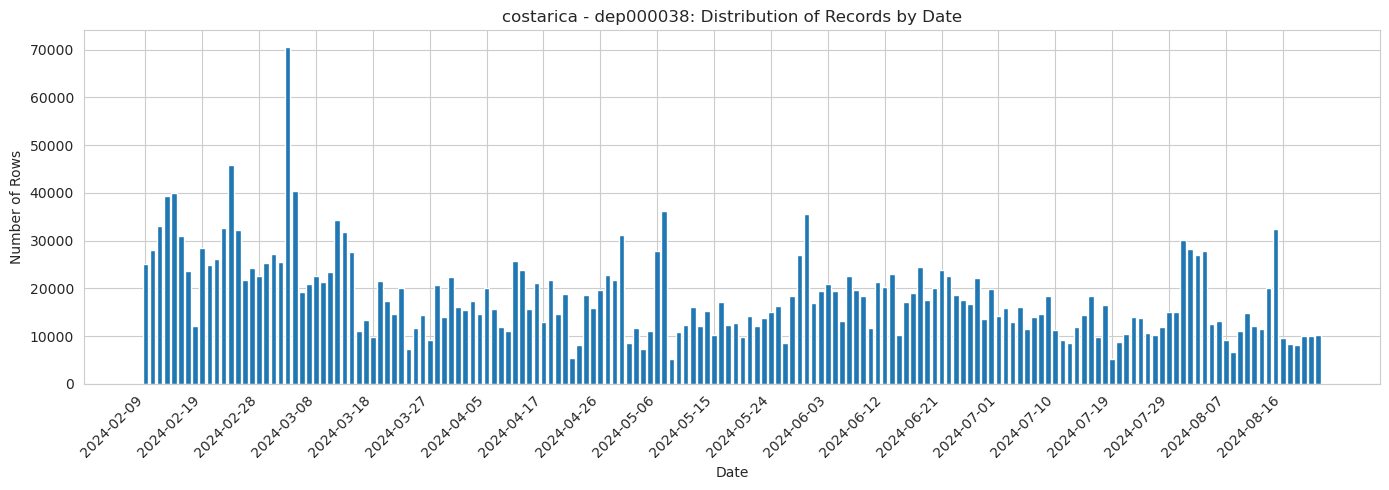


    Top 5 dates by record count:
      2024-02-09: 25152 rows
      2024-02-10: 27982 rows
      2024-02-12: 33054 rows
      2024-02-13: 39444 rows
      2024-02-14: 39887 rows

  Deployment: dep000039
  ------------------------------------------------------------
    Number of files: 15
    Start date: 2024-02-11
    End date: 2024-12-09
    Total records: 301867


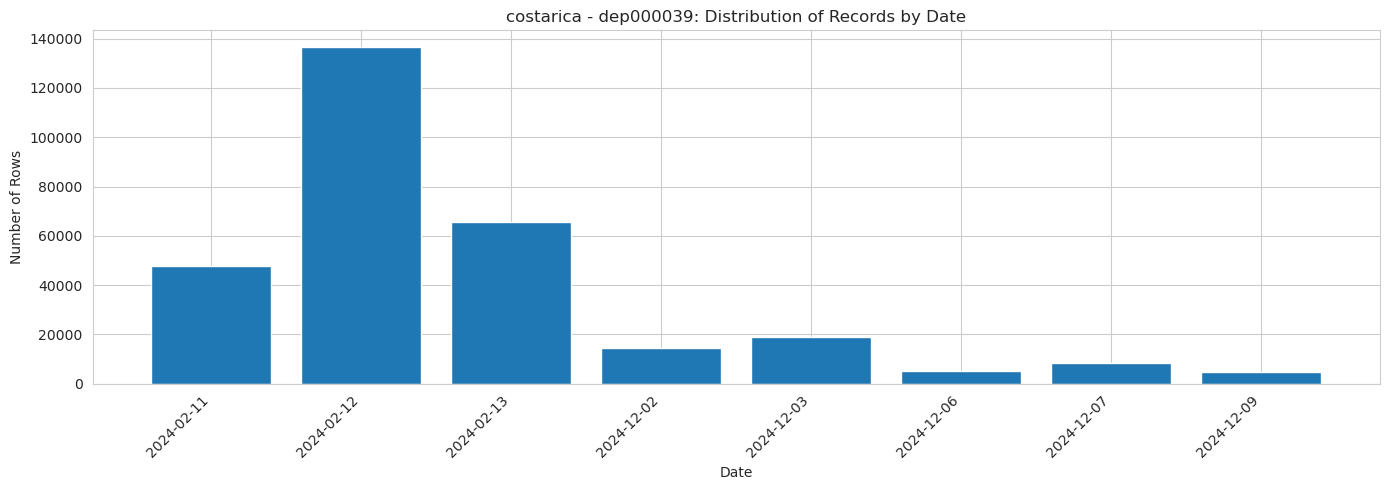


    Top 5 dates by record count:
      2024-02-11: 47938 rows
      2024-02-12: 136543 rows
      2024-02-13: 65634 rows
      2024-12-02: 14298 rows
      2024-12-03: 18815 rows

  Deployment: dep000040
  ------------------------------------------------------------
    Number of files: 4
    Start date: 2024-02-12
    End date: 2024-02-13
    Total records: 118631


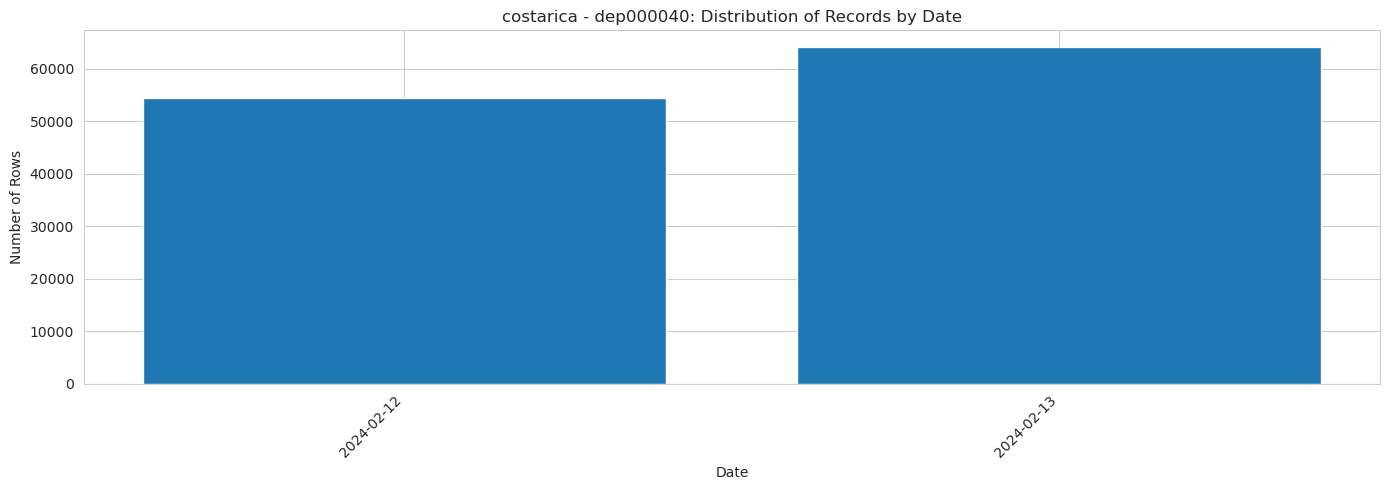


    Top 5 dates by record count:
      2024-02-12: 54509 rows
      2024-02-13: 64122 rows

REGION: kenya

  Deployment: dep000094
  ------------------------------------------------------------
    Number of files: 62
    Start date: 2024-08-07
    End date: 2024-09-05
    Total records: 771419


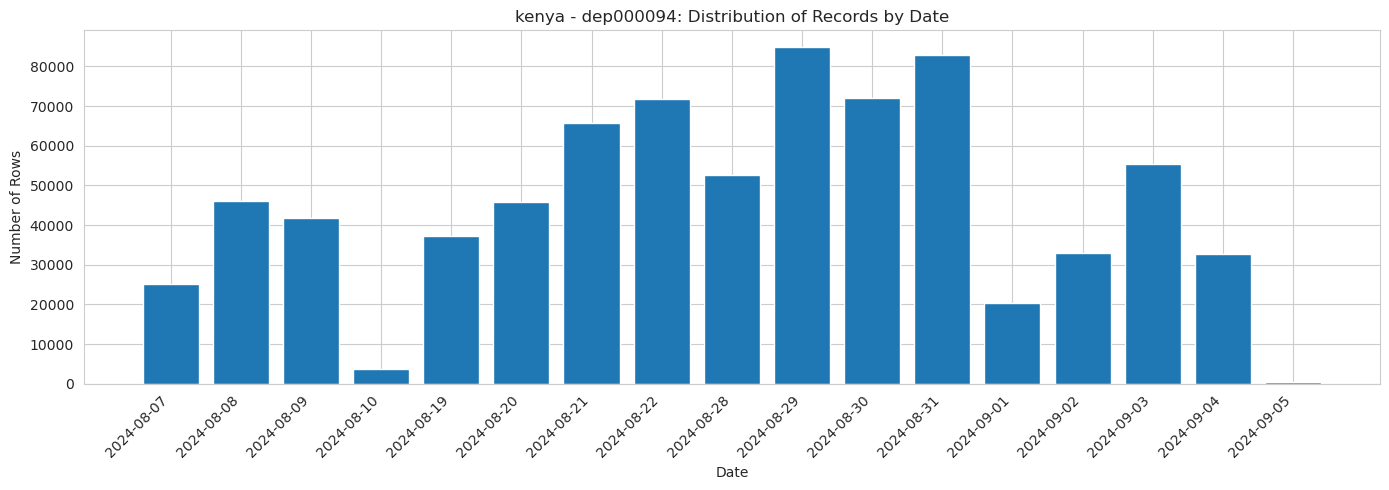


    Top 5 dates by record count:
      2024-08-07: 25019 rows
      2024-08-08: 46144 rows
      2024-08-09: 41887 rows
      2024-08-10: 3790 rows
      2024-08-19: 37348 rows

  Deployment: dep000095
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000096
  ------------------------------------------------------------
    Number of files: 155
    Start date: 2024-05-29
    End date: 2024-10-23
    Total records: 2194625


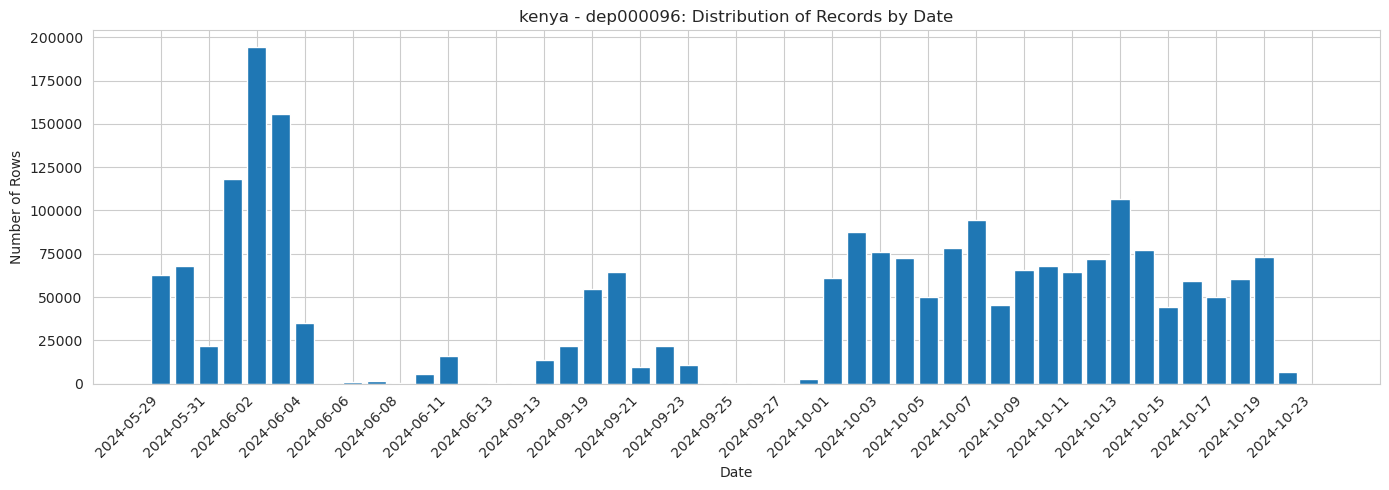


    Top 5 dates by record count:
      2024-05-29: 62929 rows
      2024-05-30: 67811 rows
      2024-05-31: 22006 rows
      2024-06-01: 117977 rows
      2024-06-02: 194246 rows

REGION: panama

  Deployment: dep000017
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000018
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000019
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000020
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000021
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000022
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000083
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000084
 

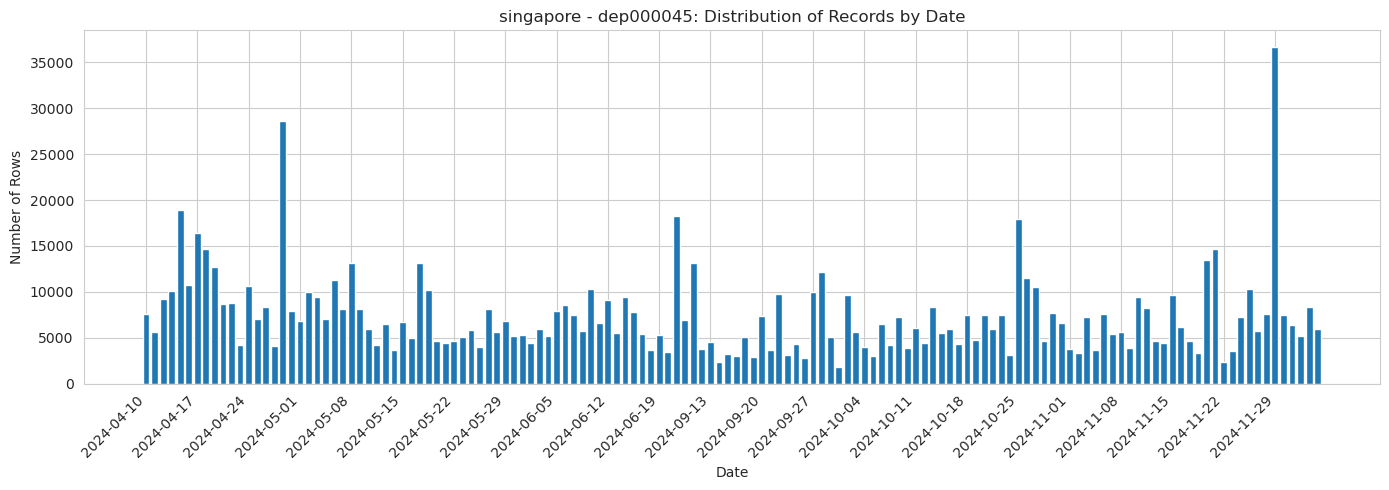


    Top 5 dates by record count:
      2024-04-10: 7593 rows
      2024-04-11: 5624 rows
      2024-04-12: 9205 rows
      2024-04-13: 10073 rows
      2024-04-15: 18942 rows

  Deployment: dep000046
  ------------------------------------------------------------


/tmp/ipykernel_841750/1216106133.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


    Number of files: 54
    Start date: 2024-04-11
    End date: 2024-06-25
    Total records: 790560


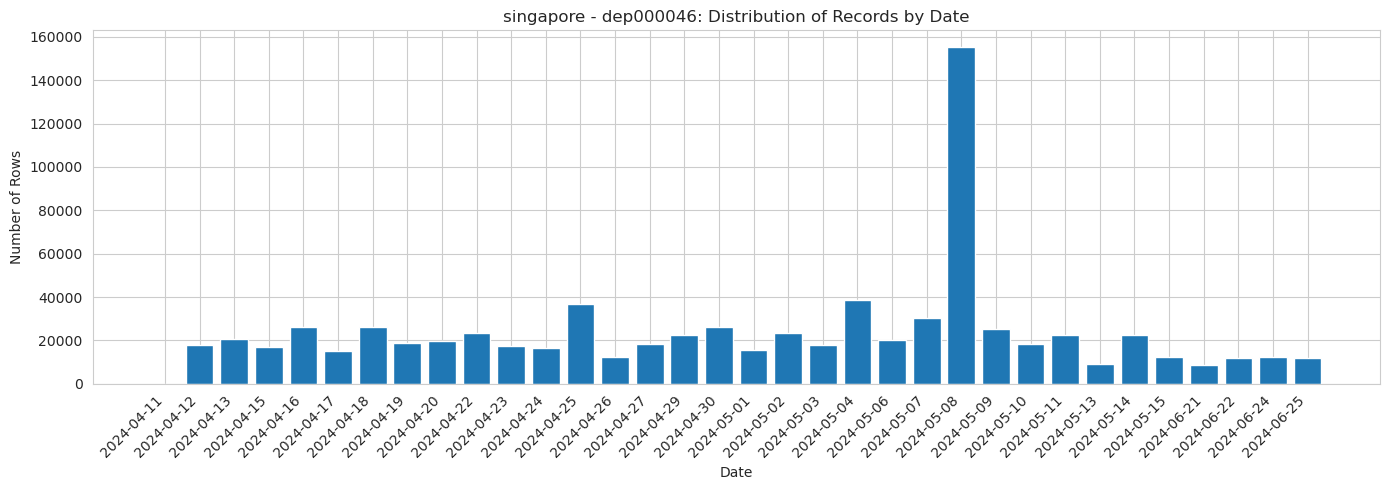


    Top 5 dates by record count:
      2024-04-11: 1 rows
      2024-04-12: 17959 rows
      2024-04-13: 20437 rows
      2024-04-15: 16865 rows
      2024-04-16: 25978 rows

  Deployment: dep000047
  ------------------------------------------------------------
    Number of files: 44
    Start date: 2024-04-12
    End date: 2024-06-24
    Total records: 256943


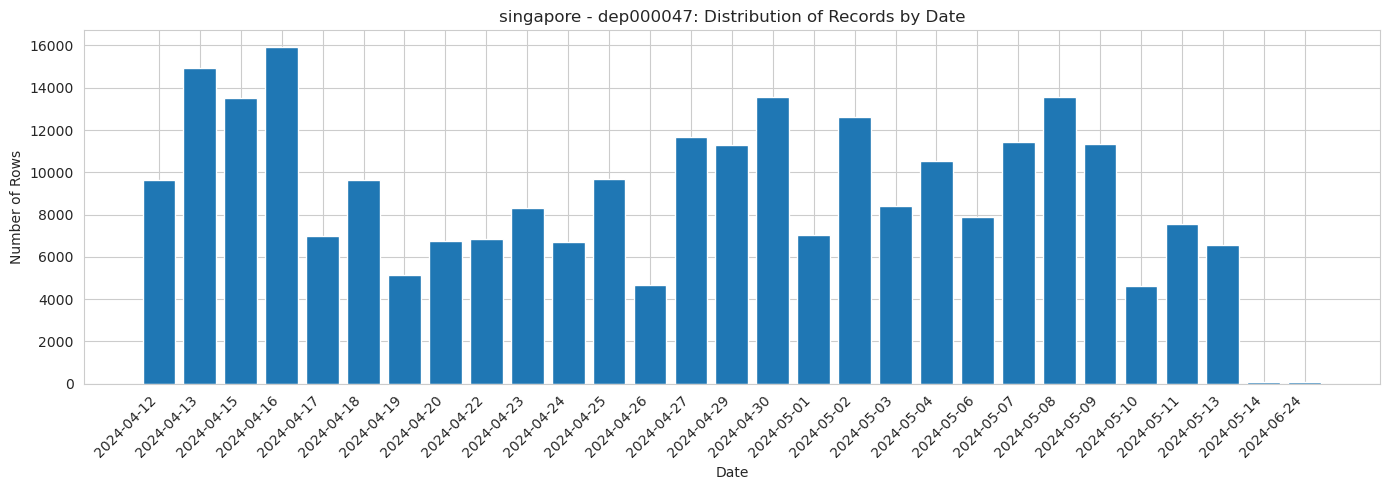


    Top 5 dates by record count:
      2024-04-12: 9646 rows
      2024-04-13: 14941 rows
      2024-04-15: 13519 rows
      2024-04-16: 15918 rows
      2024-04-17: 7003 rows

  Deployment: dep000048
  ------------------------------------------------------------
    Number of files: 2
    Start date: 2024-04-15
    End date: 2024-04-15
    Total records: 2505


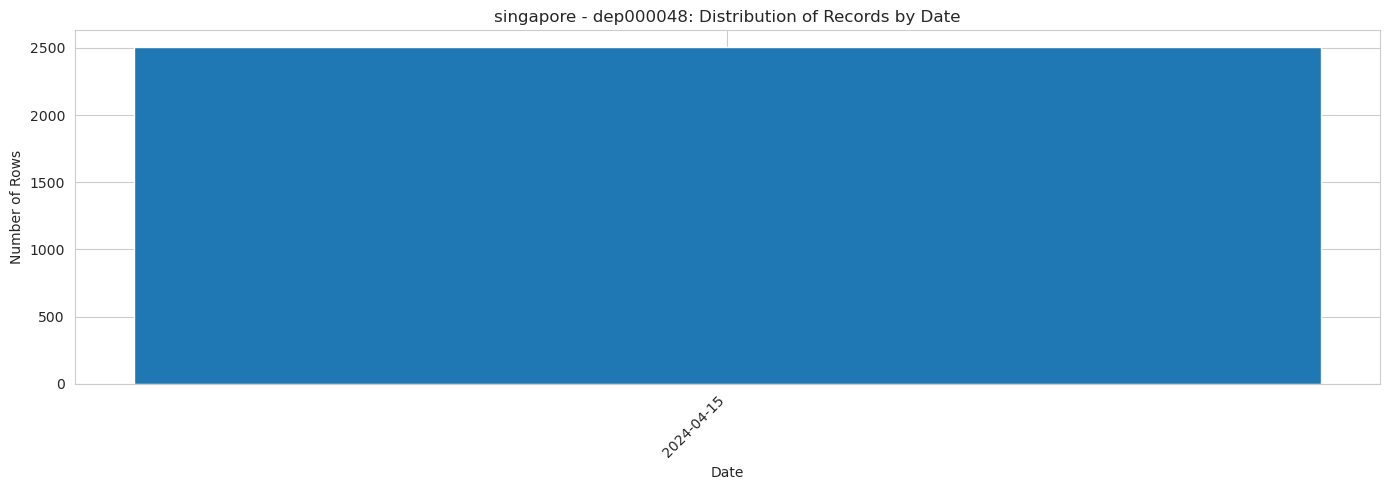


    Top 5 dates by record count:
      2024-04-15: 2505 rows

  Deployment: dep000049
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000050
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000051
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000052
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000053
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000054
  ------------------------------------------------------------
    No CSV files found

REGION: thailand

  Deployment: dep000074
  ------------------------------------------------------------


/tmp/ipykernel_841750/1216106133.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_841750/1216106133.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_841750/1216106133.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_841750/1216106133.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_841750/1216106133.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_841750/1216106133.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_

    Number of files: 233
    Start date: 2024-07-23
    End date: 2024-12-31
    Total records: 6117411


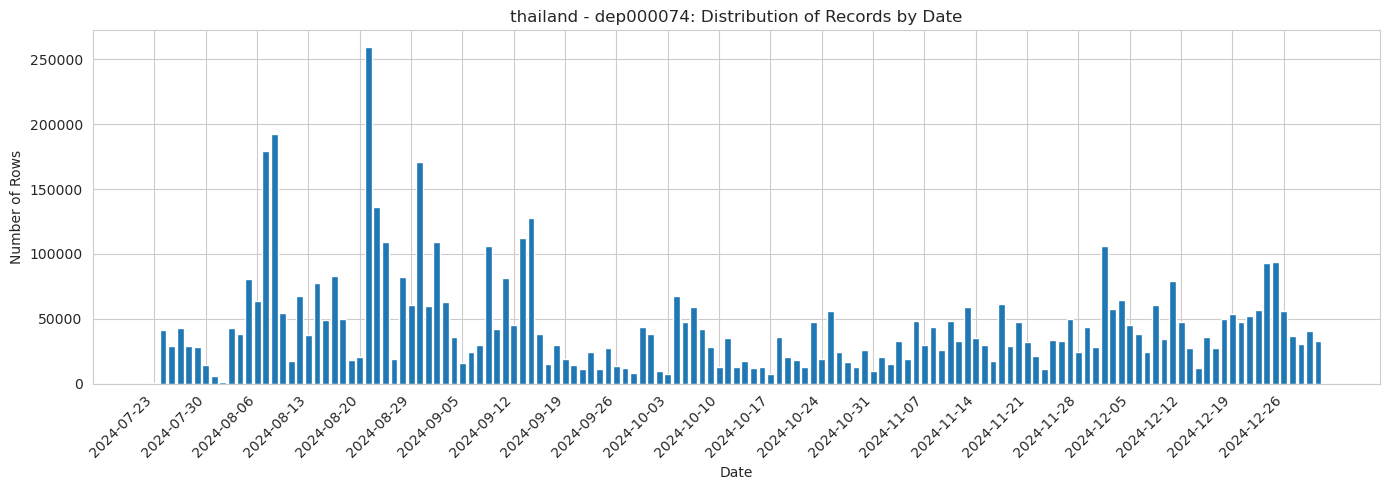


    Top 5 dates by record count:
      2024-07-23: 272 rows
      2024-07-24: 41313 rows
      2024-07-25: 29172 rows
      2024-07-26: 43259 rows
      2024-07-27: 28985 rows

  Deployment: dep000075
  ------------------------------------------------------------


/tmp/ipykernel_841750/1216106133.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_841750/1216106133.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_841750/1216106133.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_841750/1216106133.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_841750/1216106133.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_841750/1216106133.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_

    Number of files: 77
    Start date: 2024-07-26
    End date: 2024-09-16
    Total records: 2669526


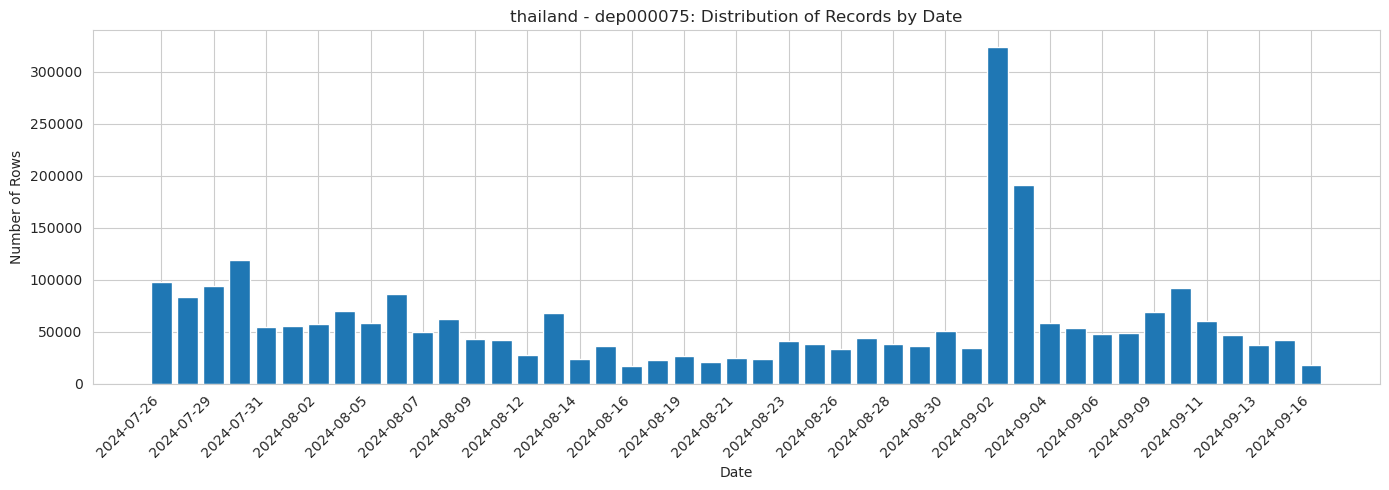


    Top 5 dates by record count:
      2024-07-26: 97811 rows
      2024-07-27: 83466 rows
      2024-07-29: 93567 rows
      2024-07-30: 119217 rows
      2024-07-31: 54884 rows

  Deployment: dep000076
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000077
  ------------------------------------------------------------
    No CSV files found

  Deployment: dep000078
  ------------------------------------------------------------
    No CSV files found

Analysis complete!

SUMMARY TABLE

   Region Deployment  File Count Start Date   End Date  Total Records
costarica  dep000031         239 2024-01-31 2024-08-14         947931
costarica  dep000032         508 2024-01-31 2025-02-04        4661605
costarica  dep000033         430 2024-02-02 2024-12-04        9487876
costarica  dep000034         233 2024-02-01 2025-02-01        2633566
costarica  dep000035           5 2024-04-29 2024-05-29         215089
costarica  dep000036           

In [ ]:
# Main analysis loop
results = {}
summary_data = []  # List to collect summary data for table

for region in sorted(regions):
    region_path = base_path / f"{region}_inferences"

    print(f"\n{'='*80}")
    print(f"REGION: {region}")
    print(f"{'='*80}")

    # Find all deployment directories (dep*.csv pattern seems wrong - looking for dep* directories)
    deployments = sorted([d for d in region_path.glob('dep*') if d.is_dir()])

    if not deployments:
        print(f"  No deployment directories found")
        continue

    results[region] = {}

    for deployment in deployments:
        print(f"\n  Deployment: {deployment.name}")
        print(f"  {'-'*60}")

        analysis = analyze_deployment(deployment)

        if analysis is None:
            print(f"    No CSV files found")
            continue

        results[region][deployment.name] = analysis

        # Collect summary data for table
        summary_row = {
            'Region': region,
            'Deployment': deployment.name,
            'File Count': analysis['file_count'],
            'Start Date': analysis['start_date'].strftime('%Y-%m-%d') if analysis['start_date'] else 'N/A',
            'End Date': analysis['end_date'].strftime('%Y-%m-%d') if analysis['end_date'] else 'N/A',
            'Total Records': len(analysis['dates']) if analysis['dates'] is not None else 0
        }
        summary_data.append(summary_row)

        # Print summary
        print(f"    Number of files: {analysis['file_count']}")

        if analysis['dates'] is not None:
            print(f"    Start date: {analysis['start_date'].strftime('%Y-%m-%d')}")
            print(f"    End date: {analysis['end_date'].strftime('%Y-%m-%d')}")
            print(f"    Total records: {len(analysis['dates'])}")

            # Plot date distribution
            date_counts = analysis['dates']['date'].dt.date.value_counts().sort_index()

            # plt.figure(figsize=(14, 5))
            # plt.bar(range(len(date_counts)), date_counts.values)
            # plt.xlabel('Date')
            # plt.ylabel('Number of Rows')
            # plt.title(f'{region} - {deployment.name}: Distribution of Records by Date')
            # plt.xticks(range(0, len(date_counts), max(1, len(date_counts)//20)),
            #           [str(d) for d in date_counts.index[::max(1, len(date_counts)//20)]],
            #           rotation=45, ha='right')
            # plt.tight_layout()
            # plt.show()

            # # Print top dates
            # print(f"\n    Top 5 dates by record count:")
            # for date, count in date_counts.head().items():
            #     print(f"      {date}: {count} rows")
        else:
            print(f"    No date data found")

print(f"\n{'='*80}")
print(f"Analysis complete!")
print(f"{'='*80}")

# Create summary DataFrame
summary_df = pd.DataFrame(summary_data)

# Display the summary table
print(f"\n{'='*80}")
print(f"SUMMARY TABLE")
print(f"{'='*80}\n")
print(summary_df.to_string(index=False))

# Save to CSV
output_file = 'deployment_summary.csv'
summary_df.to_csv(output_file, index=False)
print(f"\n{'='*80}")
print(f"Summary table saved to: {output_file}")
print(f"{'='*80}")
